In [1]:
#Keşifçi Veri Analizi (EDA)
import pandas as pd
pd.set_option('display.max_columns', None) #Bütün değerleri eksiksiz görmek için

df = pd.read_csv(r"C:\Users\Mustafa\Desktop\Customer_Churn_Prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("veri Seti Boyutu:",df.shape)

print("\n--- Veri Tipleri ve Eksik Değer Özeti ---")

df.info() #Sütün bazlı teknik özet bilgisi için kullanılır.



veri Seti Boyutu: (7043, 21)

--- Veri Tipleri ve Eksik Değer Özeti ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-n

# İlk bakış 
-> Verimizde eksik değer yoktur.
-> "TotalCharges" veri tipi "str" olarak verilmiş ama finansal tutarlar "float64" veri tipinde olmalıdır
-> "CustomerID" gereksiz değişkendir sonraki adımda kaldırılmalıdır.
-> "SeniorCitizen" veri tipi int64 olsada aslında katagorik bir değişkendir. 

In [3]:
df=df.drop('customerID',axis=1) #1. Analize katkısı olmayan customerID sütununun silinmesi

# 2. TotalCharges sütununun sayısal (float) tipe zorlanması
# errors='coerce' parametresi, sayıya çevrilemeyen boşluk karakterlerini matematiksel eksik değere (NaN) dönüştürür.
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

print(df.isnull().sum())




gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


# !!! Çok Önemli Bir Bilgi
Pandas kütüphanesi, CSV dosyasını okurken bir sütunda tek bir boşluk karakteri (" ") dahi tespit etse, veri kaybını önlemek amacıyla tüm sütunu metin formatına çevirir. İlgili veri setinde, henüz ilk ayını doldurmamış (tenure = 0) müşterilere ait fatura kesilmediği için toplam harcama kısımları boş bırakılmış ve sisteme metin karakteri olan boşluk (" ") şeklinde aktarılmıştır. Bu nedenle .isnull() komutu boşluk karakterini bir değer olarak kabul etmiş ve eksik veri olarak saymamıştır.

# Böylece 11 adet gizli eksik veri açığa çıkmıştır.

# eksik veriler için iki standart yaklaşım mevcuttur.
Satırları Silmek: Veri kaybı oranı çok düşük olduğu için model performansını etkilemez.
Değer Atamak: Bu müşterilerin hizmet süresi sıfır olduğu için toplam harcamalarının da sıfır (0) olması mantıksal olarak doğrudur.




In [4]:
df["TotalCharges"]=df["TotalCharges"].fillna(0) # 11 adet eksik verinin 0 ile doldurulması

print("Kalan Eksik Veri Sayısı:\n", df.isnull().sum().max())

df['Churn']=df["Churn"].map({'Yes': 1, "No":0})

print(df[['TotalCharges',"Churn"]].head())
print("\nKalan Eksik Veri Sayisi",df["TotalCharges"].isnull().sum())


Kalan Eksik Veri Sayısı:
 0
   TotalCharges  Churn
0         29.85      0
1       1889.50      0
2        108.15      1
3       1840.75      0
4        151.65      1

Kalan Eksik Veri Sayisi 0


Eksik veriler mantıksal olarak sıfır ile dolduruldu.
Churn değişkeni 1 ve 0 ile değiştirildi.

In [5]:
tekrar_eden_sayisi=df.duplicated().sum() #Tekrar eden (mükerrer) satır kontrolü

print("\n--- Churn Sınıf Dağılımı(%) ---")
print(df["Churn"].value_counts(normalize=True)*100)

print("\n--- Kategorik Değişkenlerin Benzersiz Değer Sayıları ---")
kategorik_sutunlar=df.select_dtypes(include=['object']).columns
print(df[kategorik_sutunlar].nunique())



--- Churn Sınıf Dağılımı(%) ---
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

--- Kategorik Değişkenlerin Benzersiz Değer Sayıları ---
gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64


C:\Users\Mustafa\AppData\Local\Temp\ipykernel_19532\1008352339.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kategorik_sutunlar=df.select_dtypes(include=['object']).columns


->Sınıf dengesizliği mevcuttur.Bu sebeple, modelin başarısı ölçülürken salt Doğruluk (Accuracy) metriği kullanılmamalı; Kesinlik (Precision), Duyarlılık (Recall) ve F1 Skoru gibi metrikler dikkate alınmalıdır.
->

In [6]:
internet_hizmetleri=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                       'TechSupport', 'StreamingTV', 'StreamingMovies']
for sutun in internet_hizmetleri:
    df[sutun]=df[sutun].replace({'No internet service': 'No'})

print("Sadeleştirme Sonrası Benzersiz Sınıf Sayıları:")
print(df[['MultipleLines', 'OnlineSecurity', 'TechSupport']].nunique())
print("\nGüncel Veri Seti Boyutu:", df.shape)

Sadeleştirme Sonrası Benzersiz Sınıf Sayıları:
MultipleLines     3
OnlineSecurity    2
TechSupport       2
dtype: int64

Güncel Veri Seti Boyutu: (7043, 20)


-> Veri seti incelendiğinde 6 sütunu kapsayacak şekilde birbirine tekrar etme durumu oluşmuştur. BU sebeple Replace yapılmıştır. MultipleLines düzelmemiştir. Alttaki kodda düzeltilecektir.

Güncel MultipleLines Sınıf Sayısı: 2


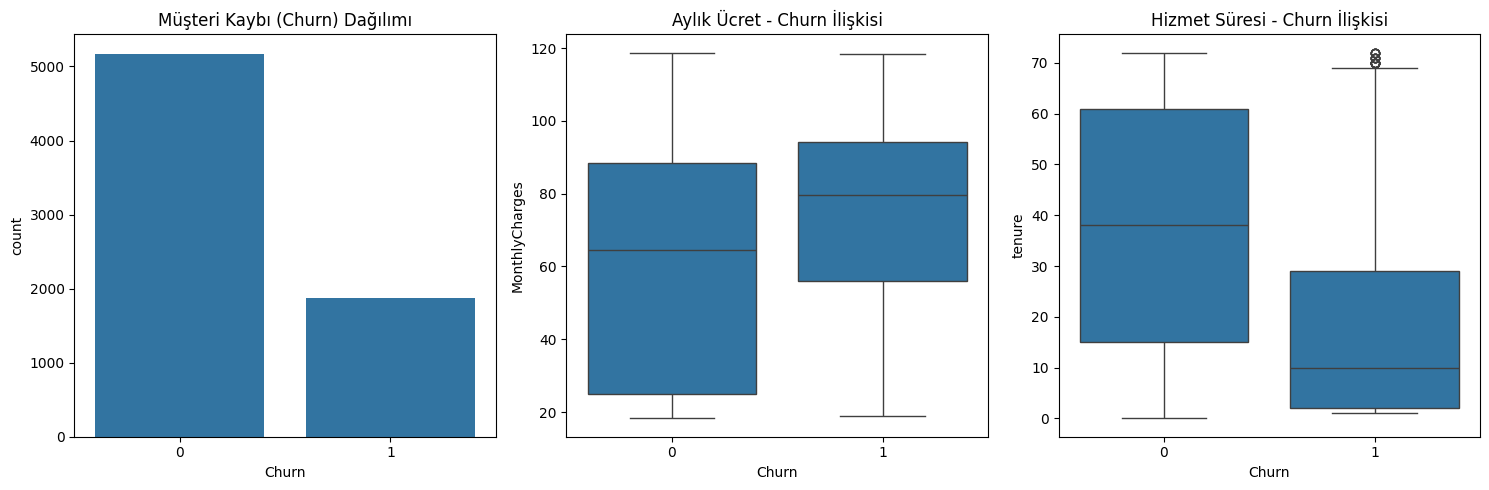

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#1. MultipleLines değişkenindeki metin formatı sorununun çözümü
df["MultipleLines"]=df["MultipleLines"].str.replace('No phone service', 'No', regex=False)
print("Güncel MultipleLines Sınıf Sayısı:", df['MultipleLines'].nunique())

# 2. Grafik alanının yapılandırılması
plt.figure(figsize=(15,5))

# 3. Churn (Kayıp) Dağılımı
plt.subplot(1,3,1)
sns.countplot(data=df,x="Churn")
plt.title('Müşteri Kaybı (Churn) Dağılımı')
# 4. Aylık Ücret (MonthlyCharges) Aykırı Değer ve İlişki Kontrolü
plt.subplot(1,3,2)
sns.boxplot(data=df,y="MonthlyCharges",x="Churn")
plt.title("Aylık Ücret - Churn İlişkisi")
# 5. Hizmet Süresi (tenure) Aykırı Değer ve İlişki Kontrolü
plt.subplot(1,3,3)
sns.boxplot(data=df,y='tenure', x='Churn')
plt.title('Hizmet Süresi - Churn İlişkisi')

plt.tight_layout()
plt.show()


->Kaybedilen müşterilerin (1 sınıfı) aylık ücret medyanı yaklaşık 80 birim seviyesindedir. Kalan müşterilerin (0 sınıfı) medyanı ise yaklaşık 65 birimdir. Kutuların konumlarına bakıldığında, 1 sınıfının kutusu genel olarak daha yukarıdadır.
->Grafikte 1 sınıfına ait kutunun üst çizgisinin dışında kalan küçük halkalar (noktalar) bulunmaktadır. Bu noktalar istatistiksel sınırların dışına taşan aykırı değerleri temsil eder. Bu durum, 60-70 ay gibi çok uzun süredir hizmet alan nadir sayıdaki sadık müşterinin de sistemi terk ettiğini göstermektedir.

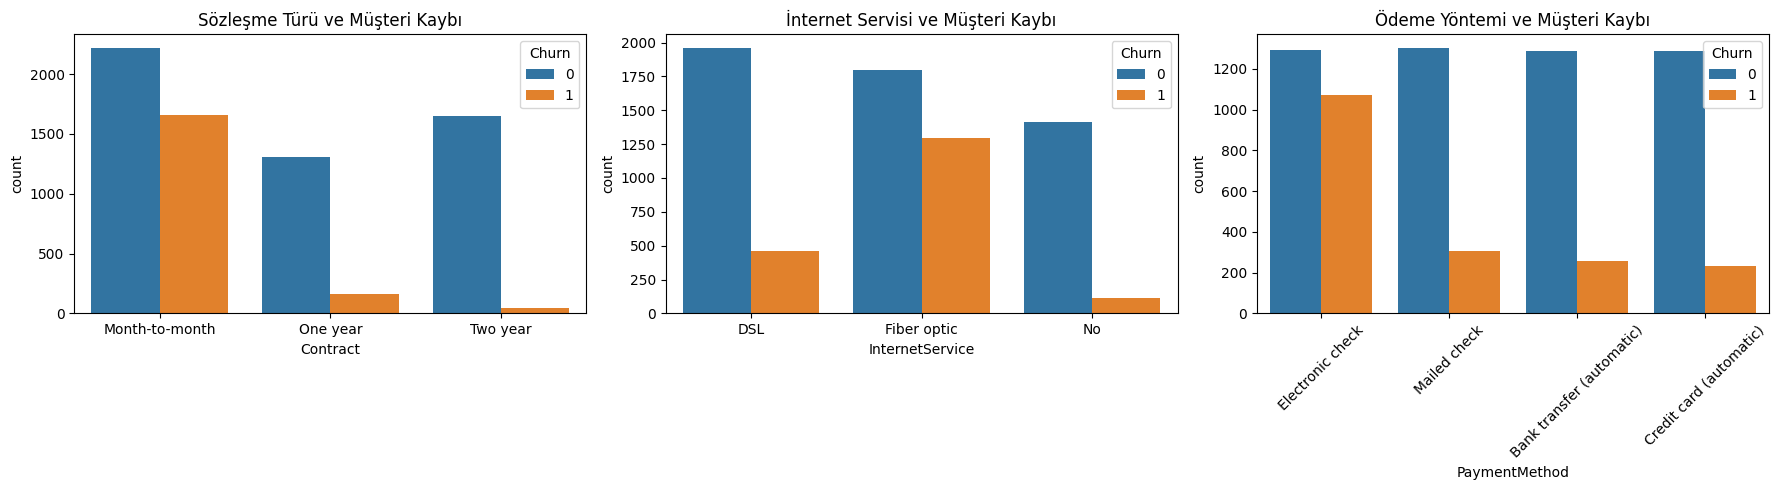

In [8]:
plt.figure(figsize=(18,5))

# 1. Sözleşme Türü (Contract) ve Churn İlişkisi
plt.subplot(1,3,1)
sns.countplot(data=df,x="Contract", hue="Churn")
plt.title('Sözleşme Türü ve Müşteri Kaybı')
# 2. İnternet Servisi (InternetService) ve Churn İlişkisi
plt.subplot(1,3,2)
sns.countplot(data=df,x="InternetService", hue="Churn")
plt.title('İnternet Servisi ve Müşteri Kaybı')
# 3. Ödeme Yöntemi (PaymentMethod) ve Churn İlişkisi
plt.subplot(1,3,3)
sns.countplot(data=df,x="PaymentMethod", hue="Churn")
plt.title('Ödeme Yöntemi ve Müşteri Kaybı')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

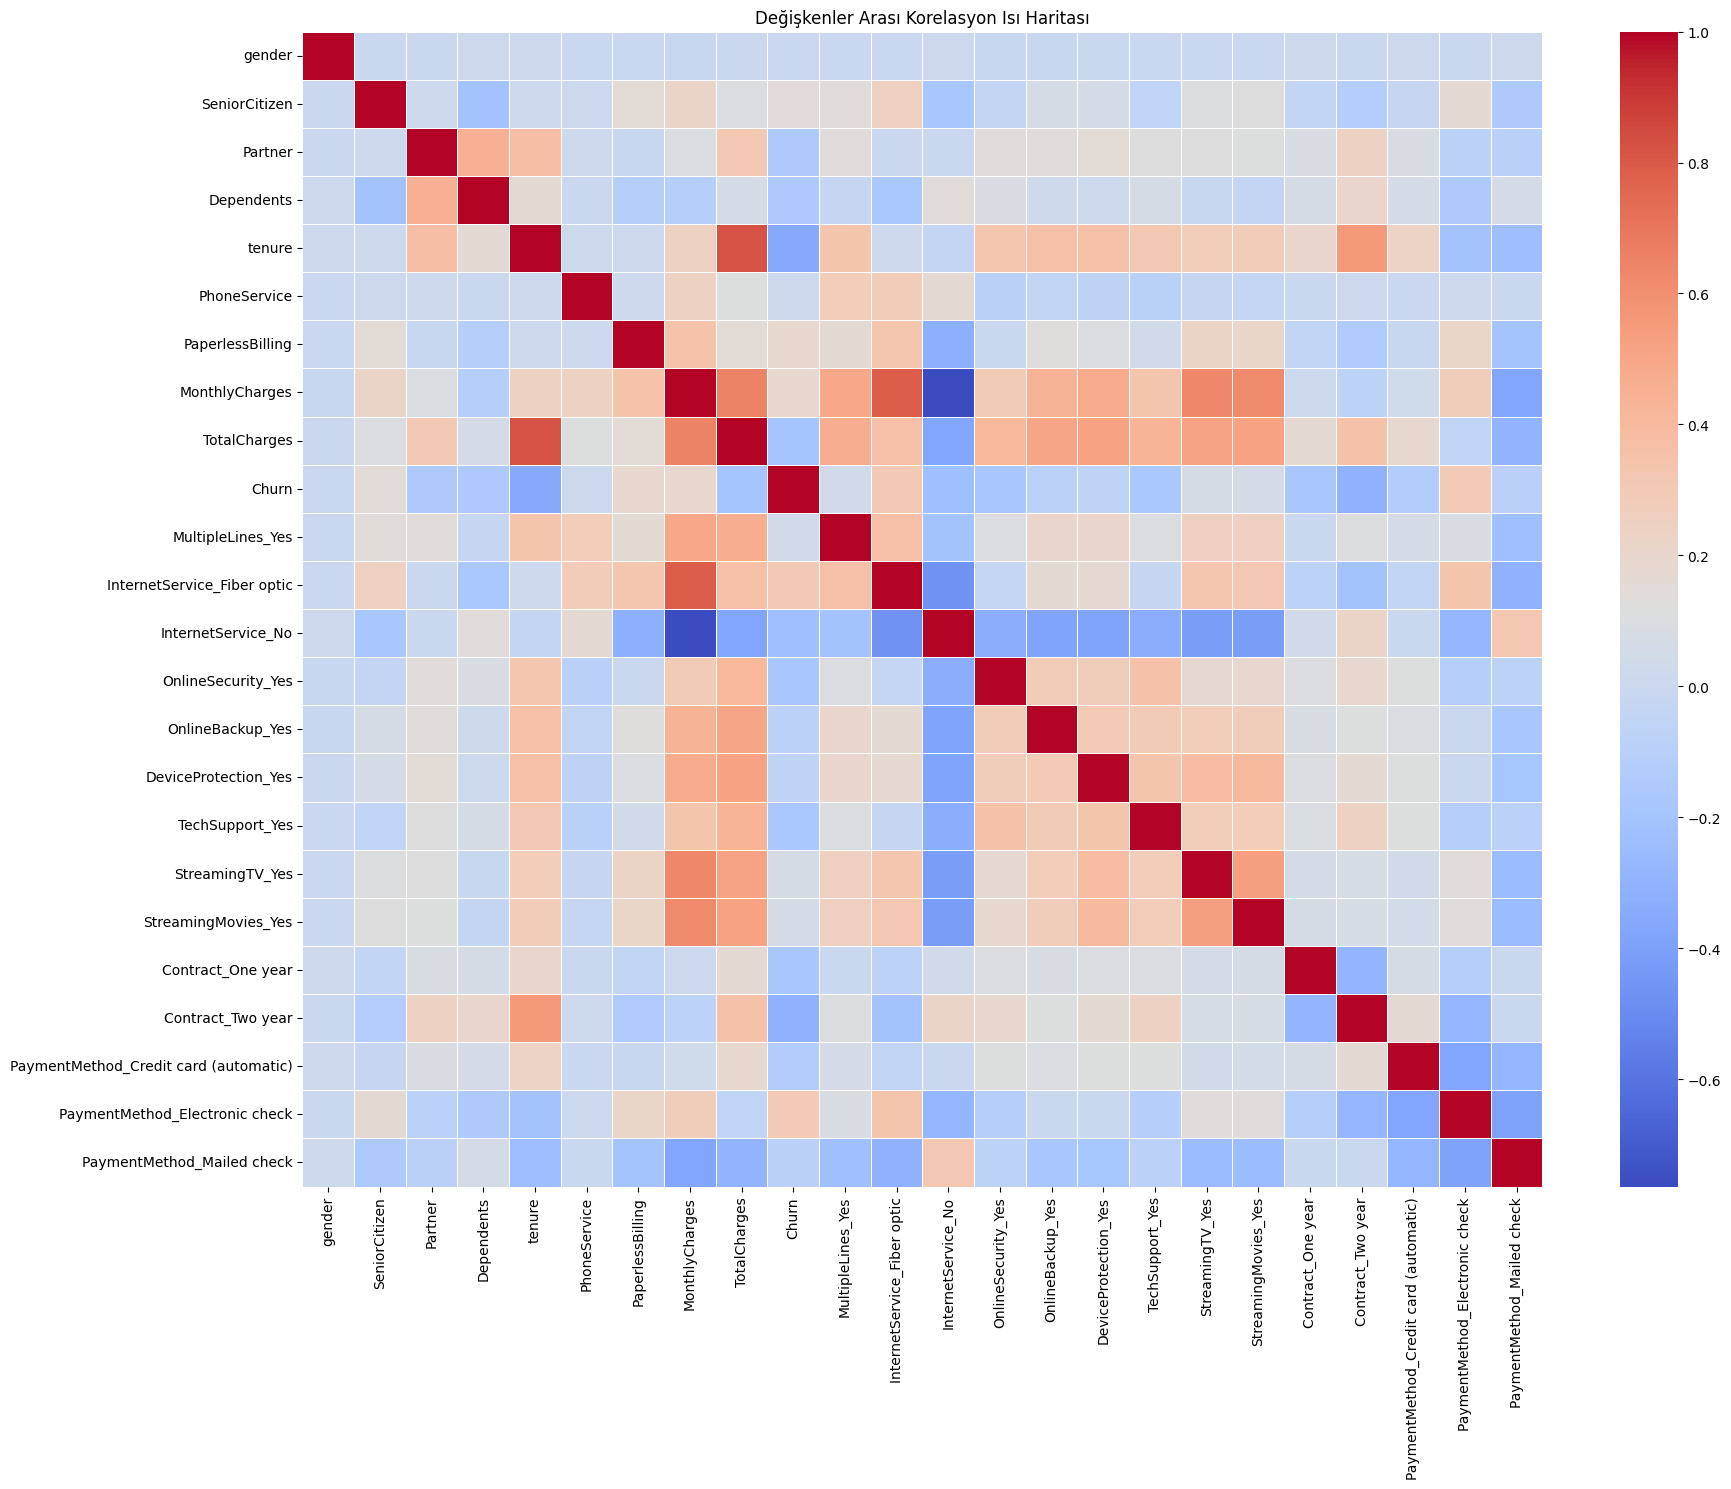

--- Churn ile Pozitif Korelasyon (Kaybı Artıranlar) ---
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
Name: Churn, dtype: float64

--- Churn ile Negatif Korelasyon (Kaybı Azaltanlar) ---
tenure               -0.352229
Contract_Two year    -0.302253
InternetService_No   -0.227890
TotalCharges         -0.198324
Contract_One year    -0.177820
OnlineSecurity_Yes   -0.171226
Name: Churn, dtype: float64


In [9]:
# 1. İki sınıflı değişkenlerin tespiti ve Label Encoding uygulanması
ikili_sutunlar=['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for sutun in ikili_sutunlar:
    df[sutun]=df[sutun].astype("category").cat.codes

# 2. Çok sınıflı değişkenlerin tespiti ve One-Hot Encoding uygulanması
coklu_sutunlar=['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                  'Contract', 'PaymentMethod']

# drop_first=True parametresi Kukla Değişken Tuzağını önler
df=pd.get_dummies(df,columns=coklu_sutunlar,drop_first=True)

# Boole (True/False) değerlerini makine öğrenmesi için 1 ve 0'a dönüştürme
bool_sutunlar=df.select_dtypes(include=["bool"]).columns
df[bool_sutunlar]=df[bool_sutunlar].astype(int)

# 3. Korelasyon Matrisinin Oluşturulması ve Görselleştirilmesi
plt.figure(figsize=(20,15))
korelasyon_matrisi=df.corr()

# Isı haritası (Heatmap) çizimi
sns.heatmap(korelasyon_matrisi,annot=False,cmap='coolwarm', linewidths=0.5)
plt.title('Değişkenler Arası Korelasyon Isı Haritası')
plt.show()

# 4. Churn ile en yüksek pozitif ve negatif ilişkiye sahip değişkenlerin listelenmesi
print("--- Churn ile Pozitif Korelasyon (Kaybı Artıranlar) ---")
print(korelasyon_matrisi['Churn'].sort_values(ascending=False).head(6))

print("\n--- Churn ile Negatif Korelasyon (Kaybı Azaltanlar) ---")
print(korelasyon_matrisi['Churn'].sort_values(ascending=True).head(6))

















->Fiber Optik ve Elektronik Çek: 0.30 seviyesindeki katsayılar, bu iki unsurun müşteri kaybında temel etken olduğunu kanıtlamaktadır.
->Aylık Ücret (MonthlyCharges): 0.19 katsayısı, fatura tutarı arttıkça sistemden çıkış ihtimalinin yükseldiğini belirtir.

->Hizmet Süresi (tenure): -0.35 ile en güçlü elde tutma faktörüdür. Sistemde kalınan süre uzadıkça ayrılma ihtimali düşmektedir.
->Uzun Vadeli Sözleşmeler: İki yıllık sözleşmeler (-0.30) müşteri sadakatini doğrudan sağlamaktadır.

!!!!
->Profesyonel makine öğrenmesi modellerinde sadece bağımsız değişkenlerin hedefle (Churn) olan ilişkisine bakılmaz. Bağımsız değişkenlerin kendi aralarındaki ilişki de incelenmelidir.İki bağımsız değişken birbirini matematiksel olarak açıklıyorsa (örneğin sistemde kalınan ay sayısı olan tenure ile toplam ödenen miktar olan TotalCharges), algoritmaya aynı bilgi iki kez verilmiş olur. Bu durum modele ezber (overfitting) yaptırır ve test başarısını düşürür, aralarında yüksek korelasyon bulunan bu değişken çiftlerinden birinin veri setinden çıkarılması (Feature Selection) standart bir prosedürdür.


In [13]:
import numpy as np
# Hedef değişken (Churn) dışarıda bırakılarak bağımsız değişkenlerin korelasyon matrisi hesaplanır
bagimsiz_degiskenler=df.drop("Churn",axis=1)
korelasyon_matrisi_bagimsiz=bagimsiz_degiskenler.corr().abs()

# Matrisin üst üçgeni alınarak aynı çiftlerin tekrar hesaplanması önlenir
ust_ucgen = korelasyon_matrisi_bagimsiz.where(np.triu(np.ones(korelasyon_matrisi_bagimsiz.shape), k=1).astype(bool))

# Korelasyon değeri 0.80'den büyük olan sütunlar listelenir
yuksek_korelasyonlu_sutunlar=[sutun for sutun in ust_ucgen.columns if any(ust_ucgen[sutun]>0.80)]
print("\nDetaylı Korelasyon Çiftleri:")
for sutun in yuksek_korelasyonlu_sutunlar:
    ilgili_satir=ust_ucgen.index[ust_ucgen[sutun]>0.80].tolist()
    print(f"- '{sutun}' değişkeni ile {ilgili_satir} arasında > %80 korelasyon bulunmaktadır.")
    



Detaylı Korelasyon Çiftleri:
- 'TotalCharges' değişkeni ile ['tenure'] arasında > %80 korelasyon bulunmaktadır.


TotalCharges (Toplam Ücret) ve tenure (Hizmet Süresi) değişkenleri arasındaki yüksek korelasyonun nedeni, toplam ücretin aylık ücret ile hizmet süresinin çarpımından elde edilmesidir. Sisteme aynı bilginin farklı formatlarda verilmesi modelin ezber yapmasına (overfitting) neden olur.

Önceki adımda hesaplanan hedef (Churn) korelasyon listesinde tenure değişkeninin etki katsayısı (-0.35), TotalCharges değişkeninden (-0.19) yüksektir. Bu veriler doğrultusunda, tahmin kapasitesi daha düşük olan TotalCharges sütununun silinmesi gerekmektedir.

In [14]:
# Çoklu doğrusallık sorunu yaratan TotalCharges sütununun silinmesi
df = df.drop('TotalCharges', axis=1)

print("Güncel Veri Seti Boyutu:", df.shape)

Güncel Veri Seti Boyutu: (7043, 23)


In [16]:
# Kalan sayısal değişkenlerin listelenmesi
sayisal_sutunlar=['tenure', 'MonthlyCharges']

for sutun in sayisal_sutunlar:
    # 1. ve 3. çeyrekliklerin hesaplanması
    q1=df[sutun].quantile(0.25)
    q3=df[sutun].quantile(0.75)

    ıqr=q3-q1

    # İstatistiksel alt ve üst sınırların belirlenmesi
    alt_sinir=q1-1.5*ıqr
    ust_sinir=q3+1.5*ıqr

    # Aykırı değer sayısının tespiti
    aykiri_sayisi=df[ (df[sutun]<alt_sinir) | (df[sutun]>ust_sinir)].shape[0]
    print(f"{sutun} değişkenindeki aykırı değer sayısı: {aykiri_sayisi}")

    # Aykırı değerlerin sınırlara baskılanması
    if aykiri_sayisi>0:
        df.loc[df[sutun]<alt_sinir,sutun]=alt_sinir
        df.loc[df[sutun]>ust_sinir,sutun]=ust_sinir
        print(f"-> {sutun} değişkenindeki aykırı değerler alt/üst sınırlara eşitlenmiştir.\n")

tenure değişkenindeki aykırı değer sayısı: 0
MonthlyCharges değişkenindeki aykırı değer sayısı: 0


Ölçeklendirme işlemi, verilerin minimum, maksimum veya ortalama değerlerini kullanarak matematiksel bir dönüştürme yapar. Eğer tüm veri setini tek seferde ölçeklendirirsek, model henüz görmemesi gereken test verisinin istatistiksel özelliklerini eğitim aşamasında öğrenir. Bu duruma makine öğrenmesinde Veri Sızıntısı (Data Leakage) denir. Modelin başarısı gerçekte olduğundan yüksek görünür ve canlı sisteme alındığında başarısız olur.

In [17]:
from sklearn.model_selection import train_test_split
# 1. Bağımsız değişkenler (X) ve Hedef değişken (y) ayrımı
X=df.drop("Churn",axis=1)
y=df["Churn"]

# 2. Veri setinin %80 Eğitim, %20 Test olacak şekilde bölünmesi
# random_state=42 parametresi, her çalıştırıldığında aynı ayrımın yapılmasını sağlar
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Eğitim Verisi Boyutu (X_train):", X_train.shape)
print("Test Verisi Boyutu (X_test):", X_test.shape)

# stratify=y parametresinin etkisini kontrol etme
print("\nEğitim Seti Churn Oranı:\n", y_train.value_counts(normalize=True))
print("\nTest Seti Churn Oranı:\n", y_test.value_counts(normalize=True))

Eğitim Verisi Boyutu (X_train): (5634, 22)
Test Verisi Boyutu (X_test): (1409, 22)

Eğitim Seti Churn Oranı:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test Seti Churn Oranı:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


Çıktınızdaki value_counts(normalize=True) satırları, bu %73.5 ve %26.5 oranlarının hem eğitim hem de test setinde birebir korunduğunu gösterir. stratify=y komutu bu eşitlemeyi sağlamaktadır.

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

sayisal_sutunlar=['tenure', 'MonthlyCharges']
# Eğitim verisinin istatistiklerinin öğrenilmesi (fit) ve dönüştürülmesi (transform)
X_train[sayisal_sutunlar]=scaler.fit_transform(X_train[sayisal_sutunlar])
# Test verisinin SADECE dönüştürülmesi (transform) - Veri sızıntısını önler
X_test[sayisal_sutunlar]=scaler.transform(X_test[sayisal_sutunlar])
# İşlem kontrolü
print("Ölçeklendirilmiş Eğitim Verisi (İlk 3 Satır):\n", X_train[sayisal_sutunlar].head(3))


Ölçeklendirilmiş Eğitim Verisi (İlk 3 Satır):
         tenure  MonthlyCharges
3738  0.102371       -0.521976
3151 -0.711743        0.337478
4860 -0.793155       -0.809013


1. Özellik Mühendisliği (Feature Engineering) Uygulaması
Önceki aşamalarda tenure (hizmet süresi) değişkeninin "0-12 Ay", "13-24 Ay" gibi müşteri sadakat gruplarına (cohort) ayrılabileceği belirtilmiştir. Bu işlem teorik olarak kalmış, koda dökülmeden doğrudan dönüştürme (Encoding) ve ölçeklendirme (Scaling) aşamalarına geçilmiştir. Algoritmalar, sürekli sayılar yerine kategorik gruplar üzerinden daha net kurallar öğrenebilmektedir.

2. Mükerrer Kayıt (Duplicate) Yönetimi
Veri inceleme adımında tekrar eden satır sayısı sorgulanmış, ancak customerID sütunu silindikten sonra tamamen aynı özellikleri taşıyan satırların veri setinden çıkarılmasına yönelik bir temizleme kodu çalıştırılmamıştır.

Sürecin bu şekilde planlanmasının temel nedenleri şunlardır:

Referans Noktası (Baseline Model) İhtiyacı: Özellik mühendisliği uygulanmadan önce verinin yalın haldeki performans kapasitesinin ölçülmesi zorunludur. Bu ölçüm, ilerleyen aşamalarda yapılacak veri manipülasyonlarının başarıyı artırıp artırmadığını kıyaslamak için temel oluşturur.

Etki Analizi: Referans noktası bulunmadan türetilen yeni değişkenlerin modele fayda mı sağladığı yoksa ezbere (overfitting) mi neden olduğu matematiksel olarak tespit edilemez.

In [21]:
from imblearn.over_sampling import SMOTE
# SMOTE algoritmasının başlatılması
smote=SMOTE(random_state=42)
# Eğitim verisi üzerinde sentetik veri üretimi
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

# İşlem öncesi ve sonrası durum kontrolü
print("--- SMOTE Öncesi Eğitim Verisi Dağılımı ---")
print(y_train.value_counts())

print("\n--- SMOTE Sonrası Eğitim Verisi Dağılımı ---")
print(y_train_smote.value_counts())



--- SMOTE Öncesi Eğitim Verisi Dağılımı ---
Churn
0    4139
1    1495
Name: count, dtype: int64

--- SMOTE Sonrası Eğitim Verisi Dağılımı ---
Churn
0    4139
1    4139
Name: count, dtype: int64


3. Yöntemin (Sınıf Ağırlıklandırma) Tercih Edilmeme Nedenleri
Sınıf ağırlıklandırma yöntemi veri setine fiziksel müdahalede bulunmaz; ceza (loss) fonksiyonunu günceller. Bu projede tercih edilmeme nedenleri şunlardır:

Algoritma Bağımlılığı: Her makine öğrenmesi algoritması (örneğin K-En Yakın Komşu - KNN) sınıf ağırlıklandırma parametresini desteklemez. SMOTE ise veriyi fiziksel olarak dengelediği için elde edilen veri seti her algoritmaya uyumlu (model-agnostic) hale gelir.

Karar Sınırı (Decision Boundary): Yalnızca matematiksel cezayı artırmak, modelin sınıflar arasındaki ayrım çizgisini öğrenmesi için yeterli fiziksel veriyi sağlamayabilir. SMOTE, sentetik veri noktaları üreterek azınlık sınıfının veri alanını genişletir ve modelin genelleme kapasitesini artırır.

"Her dengesizlikte aşırı örnekleme (oversampling) mi kullanırız?" sorunuzun yanıtı hayırdır. Kullanılacak strateji, verinin boyutuna ve problemin yapısına göre değişir:

Büyük Veri Setleri: Milyonlarca satırdan oluşan verilerde alt örnekleme (undersampling) tercih edilir. Bu tür hacimli verilerde aşırı örnekleme yapmak, donanım limitlerini aşar ve işlem sürelerini verimsiz hale getirir.

Hassas Alanlar: Tıbbi teşhis veya finansal anomali (fraud) tespiti gibi alanlarda sentetik veri üretmek, gerçek dışı kalıplar oluşturma riski taşır. Bu durumlarda veriye dokunulmaz, algoritmaların ceza parametreleri artırılarak sınıf ağırlıklandırma (class weighting) kullanılır.

Hafif Dengesizlikler: Sınıflar arası oranın %40'a %60 olduğu senaryolarda veriye fiziksel müdahale edilmez. Yalnızca model değerlendirme metrikleri (Doğruluk yerine F1 Skoru kullanımı gibi) değiştirilir.